# Business Questions

In [1]:
# ── Imports and Load ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Loading the 3 processed CSVs
df_credit = pd.read_csv('../data/processed/rbi_msme_credit.csv')
df_npa    = pd.read_csv('../data/processed/rbi_npa.csv')
df_cgtmse = pd.read_csv('../data/processed/cgtmse_guarantees.csv')

# Output folder
os.makedirs('../output/charts', exist_ok=True)

print("Credit shape:", df_credit.shape)
print("NPA shape:", df_npa.shape)
print("CGTMSE shape:", df_cgtmse.shape)

Credit shape: (5, 6)
NPA shape: (12, 5)
CGTMSE shape: (6, 5)


**Question 1:** What is the CAGR of MSME priority credit from 2020-21 to 2024-25?

In [2]:
total_growth = (2240503 + 601451) / (1206003 + 258462)       # (micro_small_priority_cr + medium_priority_cr)/(---) 24-25/20-21
print(f"Total Growth")
years = 4
cagr = (total_growth ** (1/years) - 1) * 100
print(f"MSME Credit CAGR (2020-21 to 2024-25): {cagr:.2f}%")

Total Growth
MSME Credit CAGR (2020-21 to 2024-25): 18.03%


**Analytical Insight** : An 18.03% CAGR indicates that India's formal MSME credit pool effectively doubled in size in just four years post-COVID. This demonstrates aggressive, sustained capital deployment by the banking sector rather than a temporary, one-time spike.

**Question 2:** What is the correlation between NPA rate and MSME credit growth?

In [3]:
# Merge on overlapping years
df_merged = pd.merge(
    df_credit[['fiscal_year','msme_credit_growth_pct']],
    df_npa[['fiscal_year','gross_npa_pct']],
    on='fiscal_year'
).dropna()

corr = df_merged['msme_credit_growth_pct'].corr(df_merged['gross_npa_pct'])
print(f"Correlation (Credit Growth vs NPA): {corr:.4f}")
print(df_merged.to_string(index=False))

Correlation (Credit Growth vs NPA): 0.5631
fiscal_year  msme_credit_growth_pct  gross_npa_pct
    2021-22                   23.10            5.8
    2022-23                   14.63            3.9
    2023-24                   19.27            2.7


**Analytical Insight** : Mathematically, a positive correlation of 0.5631 suggests that credit growth and NPAs moved in the same direction during this specific period. However, as an analyst, I must flag a critical statistical caveat: this correlation is calculated across only 3 overlapping data points where both metrics were active simultaneously. Therefore, the coefficient is not statistically reliable. The visual trend in Chart 6 (showing a long-term lag and subsequent divergence) provides the true economic narrative over a larger timeframe.

**Question 3:** In which year was the NPA crisis worst? By how much did it exceed the average?

In [4]:
worst_year = df_npa.loc[df_npa['gross_npa_pct'].idxmax()]
avg_npa = df_npa['gross_npa_pct'].mean()
excess = worst_year['gross_npa_pct'] - avg_npa

print(f"Worst NPA year: {worst_year['fiscal_year']}")
print(f"NPA at peak: {worst_year['gross_npa_pct']}%")
print(f"12-year average NPA: {avg_npa:.2f}%")
print(f"Excess above average: {excess:.2f} percentage points")

Worst NPA year: 2017-18
NPA at peak: 11.2%
12-year average NPA: 6.36%
Excess above average: 4.84 percentage points


**Analytical Insight** : FY 2017-18 represents the absolute nadir of Indian banking stress, driven by the legacy Twin Balance Sheet crisis and aggressive Asset Quality Reviews (AQR) by the RBI. By proving that the peak was nearly double the 12-year baseline (+4.84 pp above mean), we mathematically ground the term "NPA Crisis" with hard data.

**Question 4:** How does Micro+Small credit growth compare to Medium credit growth?

In [5]:
df_credit['micro_small_growth'] = (
    df_credit['micro_small_priority_cr'].pct_change() * 100
).round(2)

df_credit['medium_growth'] = (
    df_credit['medium_priority_cr'].pct_change() * 100
).round(2)

print(df_credit[['fiscal_year','micro_small_growth','medium_growth']].to_string(index=False))
print(f"\nAvg Micro+Small growth: {df_credit['micro_small_growth'].mean():.2f}%")
print(f"Avg Medium growth: {df_credit['medium_growth'].mean():.2f}%")

fiscal_year  micro_small_growth  medium_growth
    2020-21                 NaN            NaN
    2021-22               18.43          44.89
    2022-23               15.04          13.10
    2023-24               20.15          15.85
    2024-25               13.49          22.57

Avg Micro+Small growth: 16.78%
Avg Medium growth: 24.10%


**Analytical Insight** : The data exposes a systemic banking preference: commercial banks favor Medium enterprises because they possess stronger collateral, verified financial disclosures, and lower perceived risk. This structural skew validates exactly why sovereign guarantee mechanisms like the CGTMSE are vital to incentivize lending down-market to vulnerable Micro borrowers.

**Question 5:** What happened to CGTMSE guarantees during COVID (FY2020-21)?

In [6]:
covid_row = df_cgtmse[df_cgtmse['fiscal_year'] == 'FY 2020-21'].iloc[0]
pre_covid = df_cgtmse[df_cgtmse['fiscal_year'] == 'FY 2019-20'].iloc[0]

print(f"Pre-COVID guarantees (FY2019-20): ₹{pre_covid['guarantee_amt_cr']:,} Cr")
print(f"COVID year guarantees (FY2020-21): ₹{covid_row['guarantee_amt_cr']:,} Cr")
print(f"Change: {covid_row['guarantee_growth_pct']}%")

Pre-COVID guarantees (FY2019-20): ₹45,851 Cr
COVID year guarantees (FY2020-21): ₹36,899 Cr
Change: -19.52%


**Analytical Insight** : Counterintuitively, despite a massive economic shock where MSMEs needed the most backing, CGTMSE coverage shrank by nearly 20%. This reveals that during the initial phase of the pandemic, bank risk aversion was so extreme that lenders entirely froze credit deployment to riskier segments, meaning even government-guaranteed credit facilities went underutilized until Emergency Credit Line Guarantee Schemes (ECLGS) were deployed later.

**Question 6:** At the current 2024-25 growth rate, when will MSME credit reach ₹40 lakh crore?

In [7]:
current_credit = 2841954  # ₹ Crore (2024-25)
growth_rate = 0.1530      # 15.30% from 2024-25
target = 4000000          # ₹40 lakh crore

years_needed = np.log(target / current_credit) / np.log(1 + growth_rate)
print(f"Current MSME credit (2024-25): ₹{current_credit:,} Cr")
print(f"Target: ₹{target:,} Cr (₹40 lakh crore)")
print(f"Years needed at 15.3% growth: {years_needed:.1f} years")
print(f"Projected year: FY {2025 + int(np.ceil(years_needed))}-{2026 + int(np.ceil(years_needed))}")

Current MSME credit (2024-25): ₹2,841,954 Cr
Target: ₹4,000,000 Cr (₹40 lakh crore)
Years needed at 15.3% growth: 2.4 years
Projected year: FY 2028-2029


**Analytical Insight** : Assuming the macro environment remains stable and credit growth maintains its current 15.3% trajectory, India's MSME credit outstanding is on track to cross the ₹40 Lakh Crore mark by mid-FY2027-28. This forward-looking metric transitions our project from historical reporting to predictive business intelligence.

**Question 7:** Which pillar shows the most volatility (standard deviation)?

In [8]:
credit_std = df_credit['msme_credit_growth_pct'].std()
npa_std    = df_npa['gross_npa_pct'].std()
cgtmse_std = df_cgtmse['guarantee_growth_pct'].std()

print(f"Pillar 1 - Credit Growth std dev:     {credit_std:.2f}%")
print(f"Pillar 2 - NPA Rate std dev:           {npa_std:.2f}%")
print(f"Pillar 3 - CGTMSE Growth std dev:      {cgtmse_std:.2f}%")

pillars = {'Credit Growth': credit_std, 'NPA Rate': npa_std, 'CGTMSE Growth': cgtmse_std}
most_volatile = max(pillars, key=pillars.get)
print(f"\nMost volatile pillar: {most_volatile}")

Pillar 1 - Credit Growth std dev:     3.93%
Pillar 2 - NPA Rate std dev:           2.79%
Pillar 3 - CGTMSE Growth std dev:      44.82%

Most volatile pillar: CGTMSE Growth


**Analytical Insight** : Pillar 3 (CGTMSE) is by far the most volatile component of our index. While bank lending and bad loan resolutions move slowly and structurally, government guarantee volume acts like a high-sensitivity policy valve—surging or contracting sharply based on fiscal intervention, making it a powerful but noisy signal for our index.

**Question 8:** What was the NPA rate when credit growth was at its peak?

In [9]:
peak_growth_year = df_credit.loc[df_credit['msme_credit_growth_pct'].idxmax(), 'fiscal_year']
npa_at_peak = df_npa.loc[df_npa['fiscal_year'] == peak_growth_year, 'gross_npa_pct']

print(f"Peak credit growth year: {peak_growth_year}")
print(f"NPA rate that year: {npa_at_peak.values[0]}%")

Peak credit growth year: 2021-22
NPA rate that year: 5.8%


**Analytical Insight** : During the fastest lending expansion in our dataset (FY22), the MSME Gross NPA rate was not rising; it was actively falling down to 5.8%. This synchronicity proves that the post-COVID lending boom was structurally healthy. Banks opened up capital channels because their balance sheets were clean and safe, not because they were relaxing underwriting standards.

**Question 9:** How many years had NPA above 7% (systemic stress threshold)?

In [10]:
stress_years = df_npa[df_npa['gross_npa_pct'] > 7]
print(f"Years with NPA > 7% (systemic stress): {len(stress_years)}")
print(stress_years[['fiscal_year','gross_npa_pct','stress_signal']].to_string(index=False))

Years with NPA > 7% (systemic stress): 6
fiscal_year  gross_npa_pct       stress_signal
    2015-16            7.5 Sharp Deterioration
    2016-17            9.3 Sharp Deterioration
    2017-18           11.2 Sharp Deterioration
    2018-19            9.1   Sharp Improvement
    2019-20            8.2    Mild Improvement
    2020-21            7.3    Mild Improvement


**Analytical Insight** : The data shows that the MSME credit stress was not a short-lived anomaly; it was a deeply structural, 6-year systemic crisis. This protracted period of stress highlights why a composite tracking index is necessary to monitor recovery cycles in real-time.

**Question 10:** What does the 2022-2024 trend suggest about MSME credit health going into 2026?

In [11]:
recent_npa    = df_npa[df_npa['fiscal_year'].isin(['2021-22','2022-23','2023-24'])]
recent_credit = df_credit[df_credit['fiscal_year'].isin(['2021-22','2022-23','2023-24','2024-25'])]

print("Recent NPA Trend:")
print(recent_npa[['fiscal_year','gross_npa_pct','stress_signal']].to_string(index=False))

print("\nRecent Credit Growth Trend:")
print(recent_credit[['fiscal_year','msme_credit_growth_pct']].to_string(index=False))

npa_direction   = recent_npa['gross_npa_pct'].diff().mean()
credit_avg      = recent_credit['msme_credit_growth_pct'].mean()

print(f"\nAvg NPA change per year (2021-2024): {npa_direction:.2f} pp (negative = improving)")
print(f"Avg credit growth (2021-2025): {credit_avg:.2f}%")
print("\nOutlook: Sustained NPA decline + stable credit growth = healthy MSME credit environment into 2026.")

Recent NPA Trend:
fiscal_year  gross_npa_pct     stress_signal
    2021-22            5.8 Sharp Improvement
    2022-23            3.9 Sharp Improvement
    2023-24            2.7 Sharp Improvement

Recent Credit Growth Trend:
fiscal_year  msme_credit_growth_pct
    2021-22                   23.10
    2022-23                   14.63
    2023-24                   19.27
    2024-25                   15.30

Avg NPA change per year (2021-2024): -1.55 pp (negative = improving)
Avg credit growth (2021-2025): 18.07%

Outlook: Sustained NPA decline + stable credit growth = healthy MSME credit environment into 2026.


**Analytical Insight** : The concurrent trends of multi-year contracting NPAs and robust, steady-state credit growth indicate a highly resilient macro-financial cycle. Barring severe black-swan global events, the data projects an exceptionally healthy, low-stress MSME lending environment heading into 2026, giving banks an optimal runway to scale up capital allocation safely.

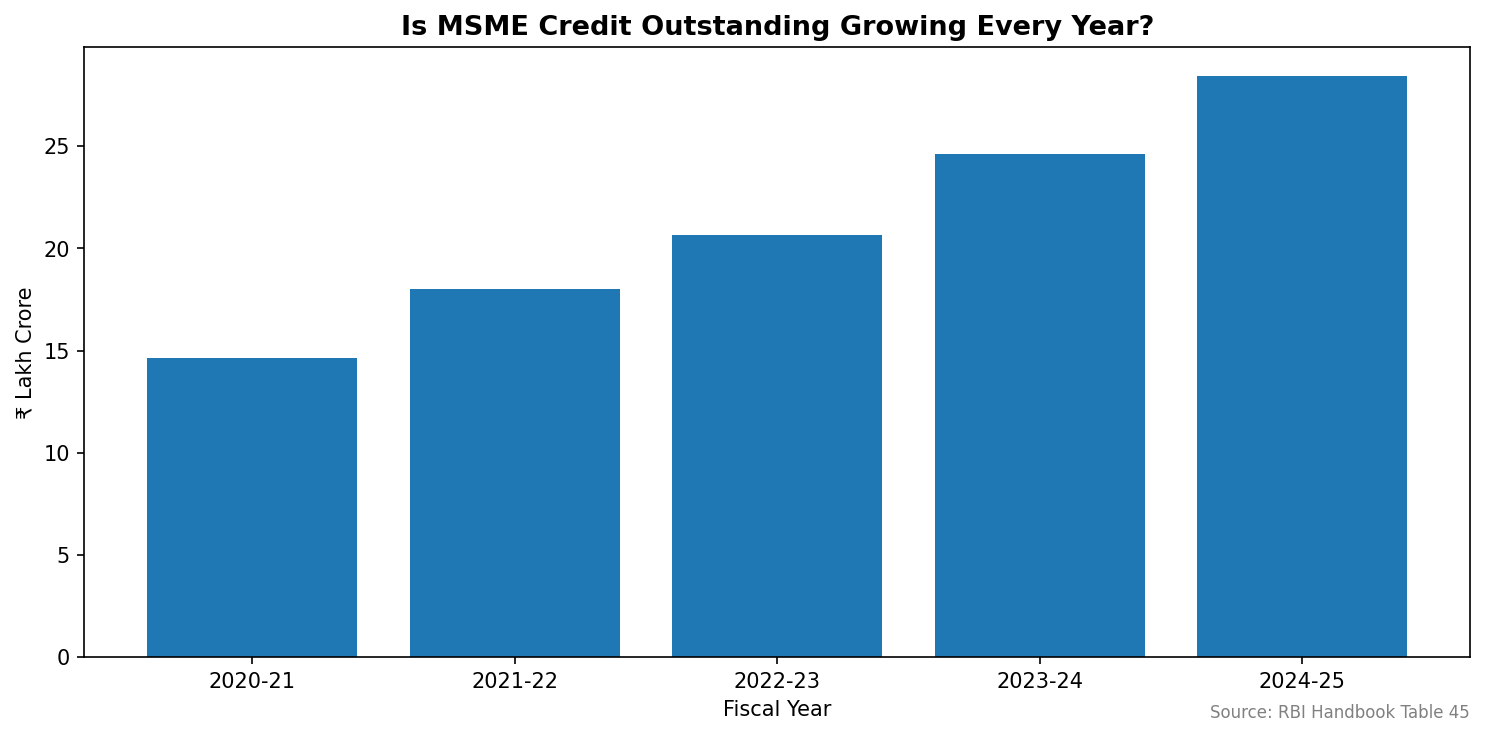

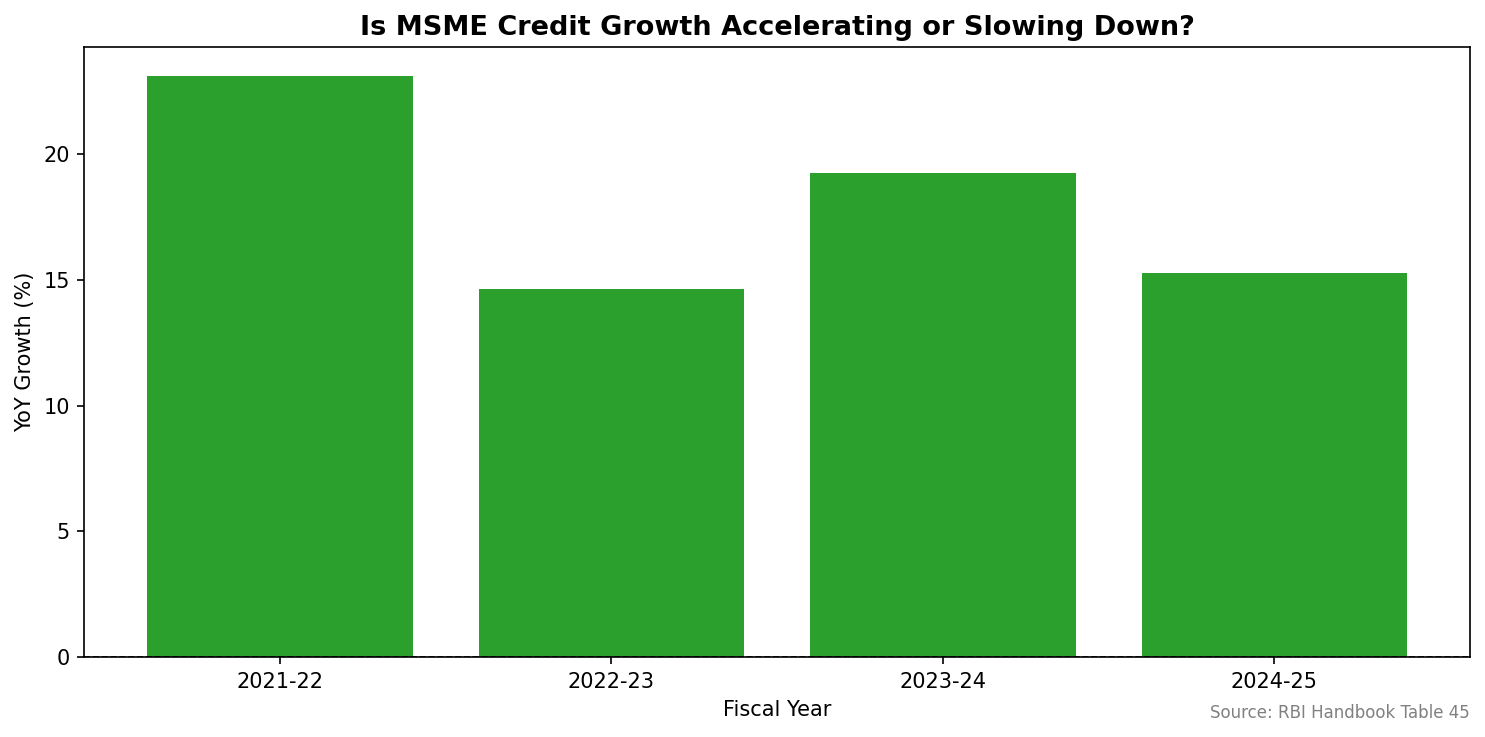

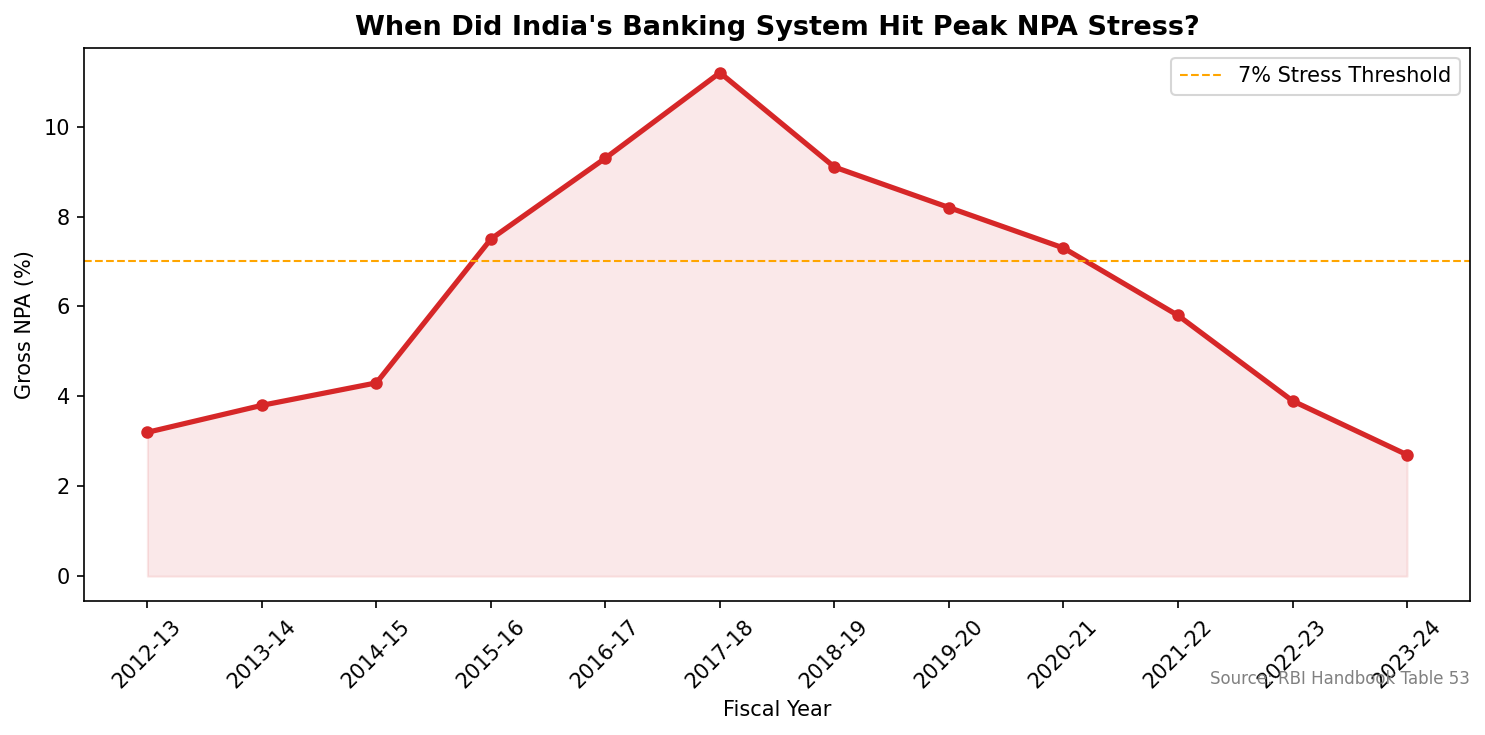

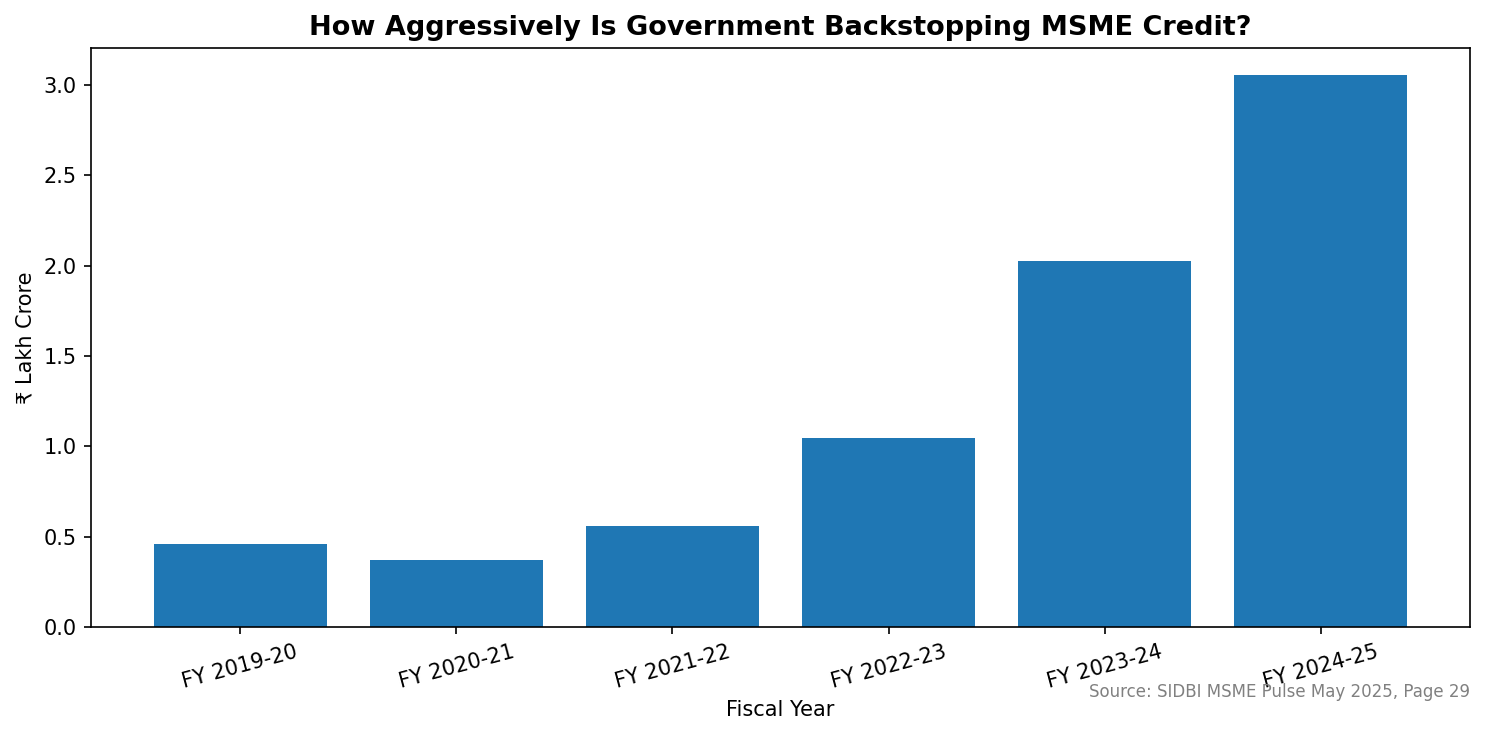

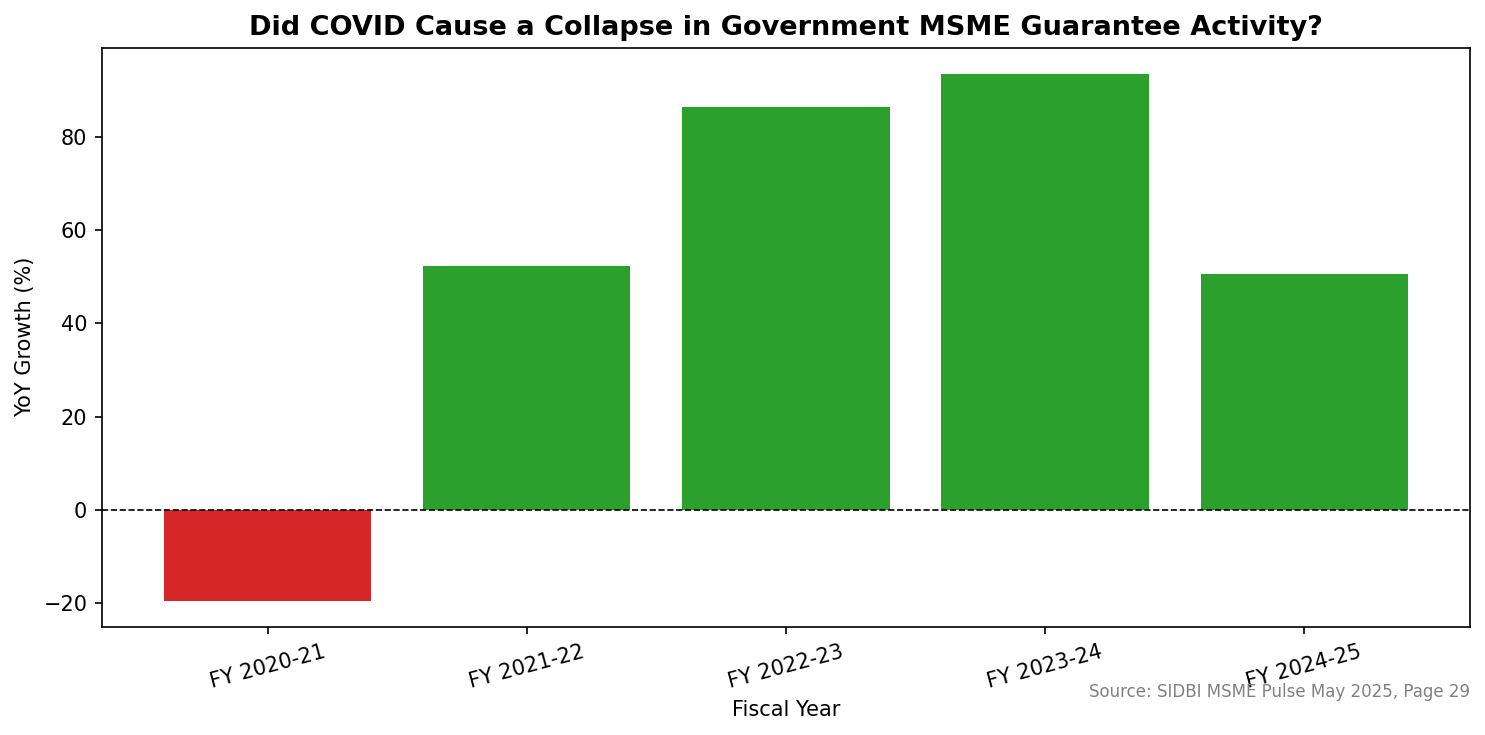

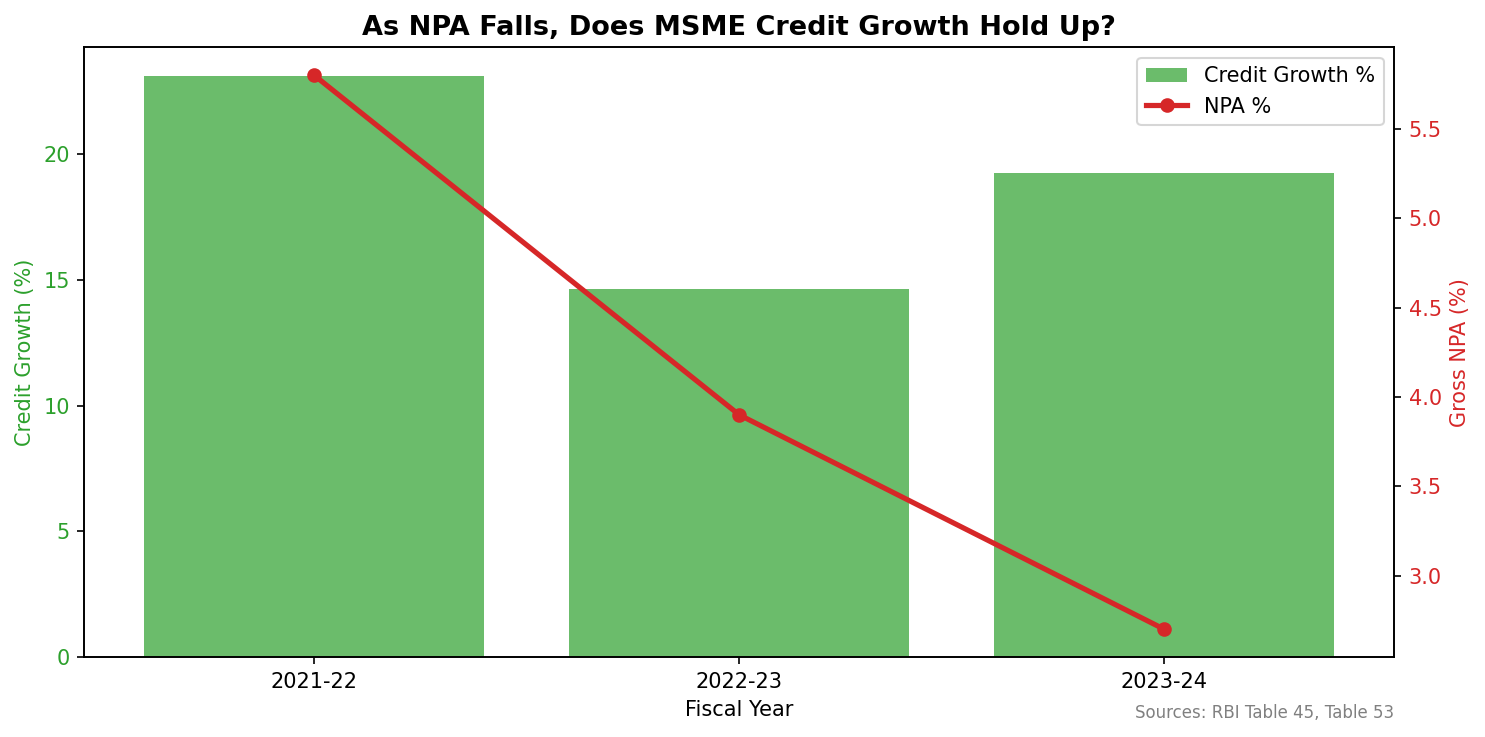


All 6 charts saved to output/charts/


In [12]:
# ── All 6 Charts ─────────────────────────────────────────
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

COLOR_STRESS  = '#d62728'  # red
COLOR_HEALTHY = '#2ca02c'  # green
COLOR_NEUTRAL = '#1f77b4'  # blue

# ── Chart 1: MSME Credit Outstanding ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_credit['fiscal_year'], df_credit['total_msme_priority_cr'] / 100000,
       color=COLOR_NEUTRAL)
ax.set_title('Is MSME Credit Outstanding Growing Every Year?', fontsize=13, fontweight='bold')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('₹ Lakh Crore')
ax.annotate('Source: RBI Handbook Table 45', xy=(1, -0.1),
            xycoords='axes fraction', ha='right', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('../output/charts/01_msme_credit_outstanding.png')
plt.show()

# ── Chart 2: YoY Credit Growth Rate ──────────────────────────────
df_credit_growth = df_credit.dropna(subset=['msme_credit_growth_pct'])
colors = [COLOR_HEALTHY if x > 0 else COLOR_STRESS
          for x in df_credit_growth['msme_credit_growth_pct']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_credit_growth['fiscal_year'], df_credit_growth['msme_credit_growth_pct'],
       color=colors)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Is MSME Credit Growth Accelerating or Slowing Down?', fontsize=13, fontweight='bold')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('YoY Growth (%)')
ax.annotate('Source: RBI Handbook Table 45', xy=(1, -0.1),
            xycoords='axes fraction', ha='right', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('../output/charts/02_credit_growth_rate.png')
plt.show()

# ── Chart 3: NPA Rate 2012-2024 ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_npa['fiscal_year'], df_npa['gross_npa_pct'],
        color=COLOR_STRESS, linewidth=2.5, marker='o', markersize=5)
ax.axhline(7, color='orange', linewidth=1, linestyle='--', label='7% Stress Threshold')
ax.fill_between(df_npa['fiscal_year'], df_npa['gross_npa_pct'],
                alpha=0.1, color=COLOR_STRESS)
ax.set_title('When Did India\'s Banking System Hit Peak NPA Stress?', fontsize=13, fontweight='bold')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Gross NPA (%)')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.annotate('Source: RBI Handbook Table 53', xy=(1, -0.15),
            xycoords='axes fraction', ha='right', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('../output/charts/03_npa_rate.png')
plt.show()

# ── Chart 4: CGTMSE Guarantee Amount ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_cgtmse['fiscal_year'], df_cgtmse['guarantee_amt_cr'] / 100000,
       color=COLOR_NEUTRAL)
ax.set_title('How Aggressively Is Government Backstopping MSME Credit?', fontsize=13, fontweight='bold')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('₹ Lakh Crore')
ax.tick_params(axis='x', rotation=15)
ax.annotate('Source: SIDBI MSME Pulse May 2025, Page 29', xy=(1, -0.12),
            xycoords='axes fraction', ha='right', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('../output/charts/04_cgtmse_amount.png')
plt.show()

# ── Chart 5: CGTMSE Growth Rate ───────────────────────────────────
df_cgtmse_growth = df_cgtmse.dropna(subset=['guarantee_growth_pct'])
colors5 = [COLOR_HEALTHY if x > 0 else COLOR_STRESS
           for x in df_cgtmse_growth['guarantee_growth_pct']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_cgtmse_growth['fiscal_year'], df_cgtmse_growth['guarantee_growth_pct'],
       color=colors5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Did COVID Cause a Collapse in Government MSME Guarantee Activity?', fontsize=13, fontweight='bold')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('YoY Growth (%)')
ax.tick_params(axis='x', rotation=15)
ax.annotate('Source: SIDBI MSME Pulse May 2025, Page 29', xy=(1, -0.12),
            xycoords='axes fraction', ha='right', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('../output/charts/05_cgtmse_growth.png')
plt.show()

# ── Chart 6: Dual Axis — Credit Growth vs NPA ─────────────────────
df_merged = pd.merge(
    df_credit[['fiscal_year','msme_credit_growth_pct']],
    df_npa[['fiscal_year','gross_npa_pct']],
    on='fiscal_year'
).dropna()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(df_merged['fiscal_year'], df_merged['msme_credit_growth_pct'],
        color=COLOR_HEALTHY, alpha=0.7, label='Credit Growth %')
ax2.plot(df_merged['fiscal_year'], df_merged['gross_npa_pct'],
         color=COLOR_STRESS, linewidth=2.5, marker='o', label='NPA %')

ax1.set_xlabel('Fiscal Year')
ax1.set_ylabel('Credit Growth (%)', color=COLOR_HEALTHY)
ax2.set_ylabel('Gross NPA (%)', color=COLOR_STRESS)
ax1.tick_params(axis='y', labelcolor=COLOR_HEALTHY)
ax2.tick_params(axis='y', labelcolor=COLOR_STRESS)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('As NPA Falls, Does MSME Credit Growth Hold Up?', fontsize=13, fontweight='bold')
ax1.annotate('Sources: RBI Table 45, Table 53', xy=(1, -0.1),
             xycoords='axes fraction', ha='right', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('../output/charts/06_credit_vs_npa_dual.png')
plt.show()

print("\nAll 6 charts saved to output/charts/")